In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Change to your own Drive path
DATA_ROOT = '/content/drive/MyDrive/TeaLeafData'  # adjust if in another folder
IMAGES_DIR = f'{DATA_ROOT}/images'
MASKS_DIR  = f'{DATA_ROOT}/masks'

!ls "$IMAGES_DIR"
!ls "$MASKS_DIR"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'1. Tea algal leaf spot'  '4. Helopeltis'	'7. Healthy leaf'
'2. Brown Blight'	  '5. Red spider'
'3. Gray Blight'	  '6. Green mirid bug'
'1.Tea algal leaf spot'  '4. Helopeltis'       '7. Healthy leaf'
'2. Brown Blight'	 '5. Red spider'
'3. Gray Blight'	 '6. Green mirid bug'


In [ ]:
!pip install torch torchvision torchaudio tqdm Pillow --quiet


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


In [ ]:
from pathlib import Path
import re, random, numpy as np, math
from collections import defaultdict
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# Global params
IMG_SIZE = 256
VAL_SPLIT = 0.15
BATCH_SIZE = 6
NUM_WORKERS = 2
MAX_EPOCHS = 40
LR = 1e-3
RANDOM_SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
def _normalize_class_name(name: str) -> str:
    name = name.replace('.', ' ')
    name = re.sub(r'\s+', ' ', name).strip().lower()
    return name

def _stem_no_ext(p: Path) -> str:
    return p.stem.lower()

def _mask_match_key(p: Path) -> str:
    s = p.name.lower()
    s = re.sub(r'\.(png|jpg|jpeg)$', '', s)
    s = re.sub(r'(_mask|-mask)$', '', s)
    return s

IMAGES_DIR = Path(IMAGES_DIR)
MASKS_DIR  = Path(MASKS_DIR)

img_class_map = {_normalize_class_name(p.name): p for p in IMAGES_DIR.iterdir() if p.is_dir()}
msk_class_map = {_normalize_class_name(p.name): p for p in MASKS_DIR.iterdir() if p.is_dir()}

common_classes = sorted(set(img_class_map.keys()) & set(msk_class_map.keys()))
print("Classes found:", common_classes)

pairs = []
for cname in common_classes:
    img_folder = img_class_map[cname]
    msk_folder = msk_class_map[cname]
    img_files = [p for p in img_folder.glob('*') if p.is_file()]
    msk_files = [p for p in msk_folder.glob('*') if p.is_file()]
    msk_index = {_mask_match_key(p): p for p in msk_files}
    for img in img_files:
        key = _stem_no_ext(img)
        if key in msk_index:
            pairs.append((img, msk_index[key], cname))

print("Total paired samples:", len(pairs))


Classes found: ['1 tea algal leaf spot', '2 brown blight', '3 gray blight', '4 helopeltis', '5 red spider', '6 green mirid bug', '7 healthy leaf']
Total paired samples: 5143


In [ ]:
random.seed(RANDOM_SEED)
by_class = defaultdict(list)
for img, msk, cname in pairs:
    by_class[cname].append((img, msk))

train_items, val_items = [], []
for cname, items in by_class.items():
    random.shuffle(items)
    n_val = max(1, int(len(items)*VAL_SPLIT))
    val_items += items[:n_val]
    train_items += items[n_val:]

print("Train:", len(train_items), "| Val:", len(val_items))


Train: 4375 | Val: 768


In [ ]:
class SegDataset(Dataset):
    def __init__(self, items, image_size=256):
        self.items = items
        self.image_size = image_size

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        img_path, msk_path = self.items[idx]
        img = Image.open(img_path).convert("RGB").resize((self.image_size, self.image_size))
        msk = Image.open(msk_path).convert("L").resize((self.image_size, self.image_size))
        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        msk = (np.array(msk) > 0).astype(np.float32)
        msk = torch.from_numpy(msk).unsqueeze(0)
        return img, msk

train_dl = DataLoader(SegDataset(train_items, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl   = DataLoader(SegDataset(val_items, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x): return self.net(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch//2, 2, 2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY, diffX = x2.size(2)-x1.size(2), x2.size(3)-x1.size(3)
        x1 = F.pad(x1, [diffX//2, diffX-diffX//2, diffY//2, diffY-diffY//2])
        return self.conv(torch.cat([x2, x1], dim=1))

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, base_c=32):
        super().__init__()
        self.inc = DoubleConv(n_channels, base_c)
        self.down1 = Down(base_c, base_c*2)
        self.down2 = Down(base_c*2, base_c*4)
        self.down3 = Down(base_c*4, base_c*8)
        self.down4 = Down(base_c*8, base_c*16)
        self.up1 = Up(base_c*16, base_c*8)
        self.up2 = Up(base_c*8, base_c*4)
        self.up3 = Up(base_c*4, base_c*2)
        self.up4 = Up(base_c*2, base_c)
        self.outc = nn.Conv2d(base_c, n_classes, 1)
    def forward(self, x):
        x1 = self.inc(x); x2 = self.down1(x1)
        x3 = self.down2(x2); x4 = self.down3(x3); x5 = self.down4(x4)
        x = self.up1(x5,x4); x = self.up2(x,x3); x = self.up3(x,x2); x = self.up4(x,x1)
        return self.outc(x)

model = UNet().to(DEVICE)
print(sum(p.numel() for p in model.parameters())/1e6, "M parameters")


7.763041 M parameters


In [ ]:
def dice_coef(pred, target, eps=1e-7):
    pred = torch.sigmoid(pred) > 0.5
    inter = (pred*target).sum((1,2,3))
    union = pred.sum((1,2,3)) + target.sum((1,2,3))
    return ((2*inter+eps)/(union+eps)).mean()

def iou_coef(pred, target, eps=1e-7):
    pred = torch.sigmoid(pred) > 0.5
    inter = (pred*target).sum((1,2,3))
    union = (pred+target-pred*target).sum((1,2,3))
    return ((inter+eps)/(union+eps)).mean()

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.w = bce_weight
    def forward(self, logits, target):
        bce = self.bce(logits, target)
        probs = torch.sigmoid(logits)
        inter = (probs*target).sum((1,2,3))
        union = probs.sum((1,2,3))+target.sum((1,2,3))
        dice = (2*inter+1e-7)/(union+1e-7)
        return self.w*bce + (1-self.w)*(1-dice.mean())

criterion = BCEDiceLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))


/tmp/ipython-input-324103992.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))


In [ ]:
from torchinfo import summary

summary(model, input_size=(1, 3, 128, 128))


Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 1, 128, 128]          --
├─DoubleConv: 1-1                             [1, 32, 128, 128]         --
│    └─Sequential: 2-1                        [1, 32, 128, 128]         --
│    │    └─Conv2d: 3-1                       [1, 32, 128, 128]         864
│    │    └─BatchNorm2d: 3-2                  [1, 32, 128, 128]         64
│    │    └─ReLU: 3-3                         [1, 32, 128, 128]         --
│    │    └─Conv2d: 3-4                       [1, 32, 128, 128]         9,216
│    │    └─BatchNorm2d: 3-5                  [1, 32, 128, 128]         64
│    │    └─ReLU: 3-6                         [1, 32, 128, 128]         --
├─Down: 1-2                                   [1, 64, 64, 64]           --
│    └─Sequential: 2-2                        [1, 64, 64, 64]           --
│    │    └─MaxPool2d: 3-7                    [1, 32, 64, 64]           --
│    │    └─Doub

In [ ]:
!pip install  torchinfo

In [ ]:
best_iou = -math.inf
for epoch in range(1, MAX_EPOCHS+1):
    model.train(); train_loss = 0
    for imgs, msks in tqdm(train_dl, desc=f"Train {epoch}"):
        imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
            out = model(imgs)
            loss = criterion(out, msks)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        train_loss += loss.item()*imgs.size(0)
    train_loss /= len(train_dl.dataset)

    model.eval(); val_loss = val_iou = val_dice = 0
    with torch.no_grad():
        for imgs, msks in tqdm(val_dl, desc=f"Val {epoch}"):
            imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, msks)
            val_loss += loss.item()*imgs.size(0)
            val_iou  += iou_coef(out, msks).item()*imgs.size(0)
            val_dice += dice_coef(out, msks).item()*imgs.size(0)
    val_loss /= len(val_dl.dataset)
    val_iou  /= len(val_dl.dataset)
    val_dice /= len(val_dl.dataset)
    scheduler.step(val_iou)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} IoU={val_iou:.4f} Dice={val_dice:.4f}")

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), '/content/drive/MyDrive/unet_tealeaf_best.pt')
        print("✅ Saved new best model to Drive (IoU %.4f)" % best_iou)


Train 1:   0%|          | 0/730 [00:00<?, ?it/s]

/tmp/ipython-input-2018822359.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


Val 1:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 1: train_loss=0.2701 val_loss=0.1079 IoU=0.8170 Dice=0.8916
✅ Saved new best model to Drive (IoU 0.8170)


Train 2:   0%|          | 0/730 [00:00<?, ?it/s]

...

Val 39:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 39: train_loss=0.0687 val_loss=0.0534 IoU=0.8837 Dice=0.9347
✅ Saved new best model to Drive (IoU 0.8837)


Train 40:   0%|          | 0/730 [00:00<?, ?it/s]

Val 40:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 40: train_loss=0.0683 val_loss=0.0624 IoU=0.8633 Dice=0.9221


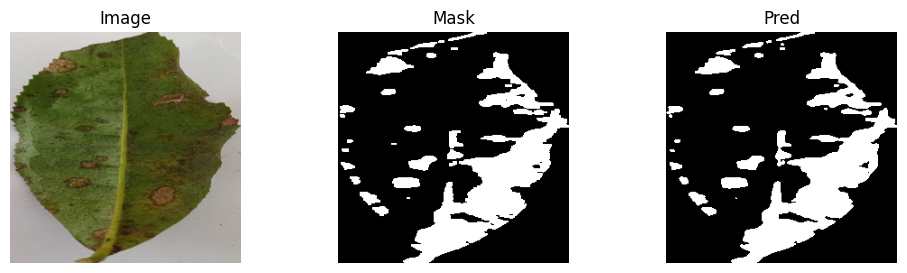

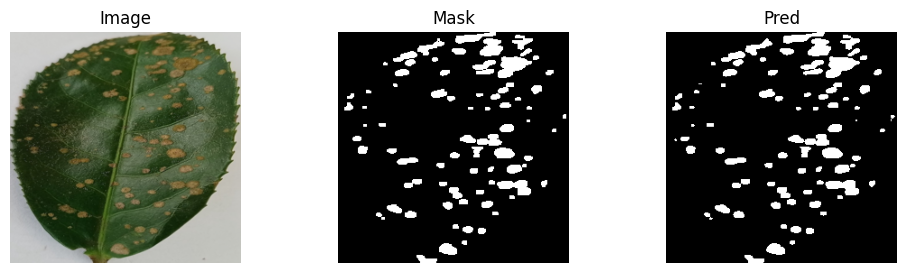

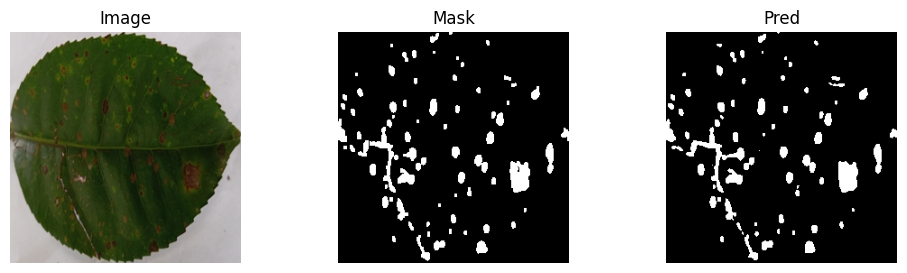

In [ ]:
model.eval()
imgs, msks = next(iter(val_dl))
imgs = imgs.to(DEVICE)
with torch.no_grad():
    preds = torch.sigmoid(model(imgs)).cpu().numpy()

for i in range(3):
    img = imgs[i].cpu().permute(1,2,0).numpy()
    img = (img*np.array([0.229,0.224,0.225]))+np.array([0.485,0.456,0.406])
    img = np.clip(img,0,1)
    gt = msks[i,0].cpu()
    pr = (preds[i,0]>0.5).astype(float)
    plt.figure(figsize=(12,3))
    plt.subplot(1,3,1); plt.imshow(img); plt.axis('off'); plt.title('Image')
    plt.subplot(1,3,2); plt.imshow(gt, cmap='gray'); plt.axis('off'); plt.title('Mask')
    plt.subplot(1,3,3); plt.imshow(pr, cmap='gray'); plt.axis('off'); plt.title('Pred')
    plt.show()


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet()
model.load_state_dict(torch.load("/content/drive/MyDrive/unet_tealeaf_best.pt", map_location=device))
model.to(device)
model.eval()

print("✅ Model loaded successfully!")



NameError: name 'UNet' is not defined

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained VGG19 model
vgg19 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

# Freeze early layers (optional, for faster training)
for param in vgg19.features.parameters():
    param.requires_grad = False

# Modify the classifier head for 7 disease classes
num_classes = 7
vgg19.classifier[6] = nn.Linear(4096, num_classes)

# Move to GPU if available
vgg19 = vgg19.to(device)
print("✅ VGG19 ready for fine-tuning.")


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transforms
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Paths (adjust if you’re using segmented images)
train_dir = "/content/drive/MyDrive/TeaLeafData/masks"
val_dir = "/content/drive/MyDrive/TeaLeafData/masks"

train_dataset = datasets.ImageFolder(train_dir, transform=train_tfms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_tfms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"✅ Loaded {len(train_dataset)} training and {len(val_dataset)} validation images.")
print(f"Classes: {train_dataset.classes}")


✅ Loaded 5158 training and 5158 validation images.
Classes: ['1.Tea algal leaf spot', '2. Brown Blight', '3. Gray Blight', '4. Helopeltis', '5. Red spider', '6. Green mirid bug', '7. Healthy leaf']


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg19.classifier.parameters(), lr=1e-4)


In [ ]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

num_epochs = 30
best_acc = 0.0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    vgg19.train()
    train_loss, train_correct = 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = vgg19(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / len(train_dataset)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Acc: {train_acc*100:.2f}% | Train Loss: {avg_train_loss:.4f}")

    # -------------------- Validation --------------------
    vgg19.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = vgg19(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / len(val_dataset)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Val Acc: {val_acc*100:.2f}% | Val Loss: {avg_val_loss:.4f}")

    # -------------------- Save Best Model --------------------
    if val_acc > best_acc:
        torch.save(vgg19.state_dict(), "/content/drive/MyDrive/vgg19_best_mask_final.pt")
        best_acc = val_acc
        print("💾 Saved best model.")

# -------------------- Plot Results --------------------
plt.figure(figsize=(12,5))

# Plot Loss
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), [a*100 for a in train_accuracies], label="Train Acc")
plt.plot(range(1, num_epochs+1), [a*100 for a in val_accuracies], label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()


NameError: name 'vgg19' is not defined

In [ ]:
from PIL import Image

def predict_image(img_path, model, classes):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    tfm = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
    img_tensor = tfm(img).unsqueeze(0).to(device)
    with torch.no_grad():
        preds = model(img_tensor)
        pred_idx = preds.argmax(1).item()
    return classes[pred_idx]

# Example usage
img_path = "/content/drive/MyDrive/TeaLeafData/images/2. Brown Blight/brown_blight_00002.jpg"
pred_label = predict_image(img_path, vgg19, train_dataset.classes)
print(f"🧩 Predicted Class: {pred_label}")


In [ ]:
torch.save(vgg19.state_dict(), "/content/drive/MyDrive/vgg19_final.pt")



In [ ]:
from torchvision import models
import torch.nn as nn

vgg19 = models.vgg19(weights=None)
vgg19.classifier[6] = nn.Linear(4096, 7)  # 7 disease classes
vgg19.load_state_dict(torch.load("/content/drive/MyDrive/vgg19_best.pt", map_location=device))
vgg19 = vgg19.to(device)
vgg19.eval()

print("✅ Model loaded for evaluation")


✅ Model loaded for evaluation


In [ ]:
import torch
from tqdm import tqdm

y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = vgg19(imgs)
        preds = torch.argmax(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


Evaluating: 100%|██████████| 322/322 [01:19<00:00,  4.06it/s]


In [ ]:
from sklearn.metrics import classification_report

print("📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))


📊 Classification Report:
                        precision    recall  f1-score   support

1. Tea algal leaf spot       1.00      0.98      0.99       418
       2. Brown Blight       0.99      1.00      0.99       506
        3. Gray Blight       1.00      1.00      1.00      1013
         4. Helopeltis       0.99      0.99      0.99       607
         5. Red spider       0.99      1.00      0.99       515
    6. Green mirid bug       1.00      1.00      1.00      1149
       7. Healthy leaf       1.00      0.99      1.00       935

              accuracy                           0.99      5143
             macro avg       0.99      0.99      0.99      5143
          weighted avg       0.99      0.99      0.99      5143



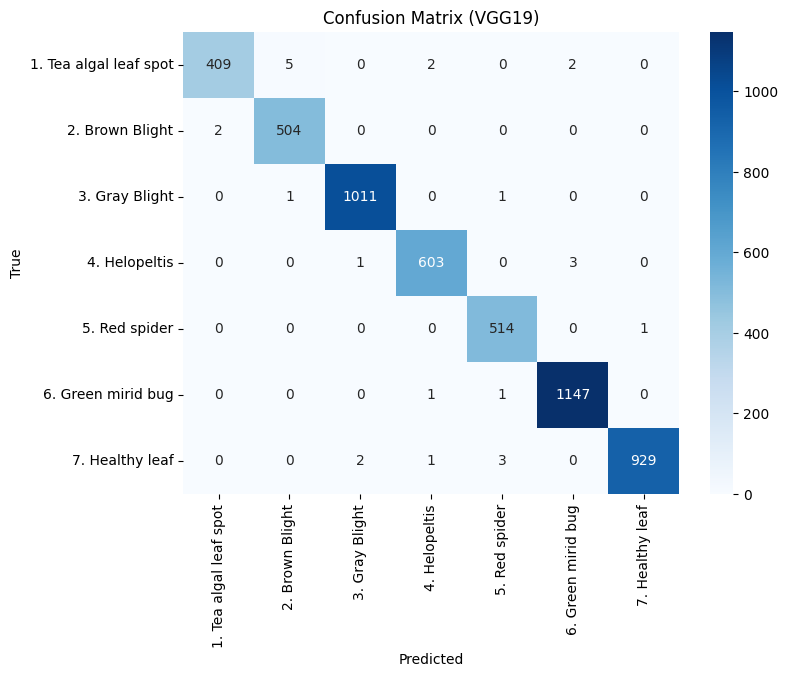

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (VGG19)")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"✅ Overall Accuracy: {acc*100:.2f}%")
print(f"🎯 Precision: {prec*100:.2f}%")
print(f"🔁 Recall: {rec*100:.2f}%")
print(f"💎 F1-Score: {f1*100:.2f}%")


✅ Overall Accuracy: 99.49%
🎯 Precision: 99.50%
🔁 Recall: 99.49%
💎 F1-Score: 99.49%


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Binarize true labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=list(range(len(train_dataset.classes))))
y_pred_scores = []

vgg19.eval()
with torch.no_grad():
    for imgs, _ in val_loader:
        imgs = imgs.to(device)
        outputs = torch.softmax(vgg19(imgs), dim=1)
        y_pred_scores.extend(outputs.cpu().numpy())

y_pred_scores = np.array(y_pred_scores)
roc_auc = roc_auc_score(y_true_bin, y_pred_scores, average="macro", multi_class="ovr")

print(f"🏁 Mean ROC–AUC Score: {roc_auc:.3f}")


🏁 Mean ROC–AUC Score: 1.000
